## Assignment 2: Diversified 4-Asset Portfolio (NVDA, XOM, TLT, GLD)
### Author: Divyanka Thakur (MSAI)

### What we’re doing
1. **Define capital-market assumptions** — expected annual returns `mu`, annual volatilities `sig`, and a correlation matrix `corr` for the four chosen assets:
   - **NVIDIA Corporation (NVDA)** — large-cap technology  
   - **Exxon Mobil Corporation (XOM)** — energy  
   - **iShares 20+ Year Treasury Bond ETF (TLT)** — bonds  
   - **SPDR Gold Shares (GLD)** — gold
2. Convert the **correlation matrix** to a **covariance matrix** `Σ` (Sigma) so we can simulate portfolio risk properly.
3. Perform **Monte Carlo portfolio sampling**:
   - **Long-only portfolios** (weights ≥ 0, sum = 1) using a Dirichlet distribution.
   - **Portfolios with short positions** (weights can be negative, normalized to sum = 1) using a soft leverage filter to keep portfolios realistic and comparable.
4. Compute **expected portfolio return** (mean) and **risk** (standard deviation) for each simulated portfolio.
5. **Visualize** the results in two panels, mirroring the R figure from Scenario 1:
   - **Left panel**: Long positions only  
   - **Right panel**: Shorts permitted (red = at least one short)

---

### Capital-Market Assumptions (Scenario 2)

- **Expected Annual Returns**
  - NVDA: 22%  
  - XOM: 8%  
  - TLT: 6%  
  - GLD: 5%

- **Volatilities (Annualized)**
  - NVDA: 50%  
  - XOM: 25%  
  - TLT: 15%  
  - GLD: 16%

- **Stylized Correlations**
  - NVDA and XOM (equities) are positively correlated.  
  - TLT (bonds) has mild negative correlation with equities.  
  - GLD (gold) has weak correlations with the other assets.

These assumptions create a **more diversified portfolio structure**, allowing us to observe how **different asset classes interact** in risk–return space and how shorting can expand the opportunity set.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Scenario 2: Custom 4 assets
# ----------------------------
assets = ["NVDA", "XOM", "TLT", "GLD"]


In [3]:
# Expected annual returns (illustrative)
mu = np.array([0.22, 0.08, 0.06, 0.05])    # NVDA, XOM, TLT, GLD

# Annualized volatilities (illustrative)
sig = np.array([0.50, 0.25, 0.15, 0.16])

# Correlation matrix (stylized diversification)
corr = np.array([
    [ 1.00,  0.40, -0.20,  0.10],  # NVDA
    [ 0.40,  1.00, -0.10,  0.05],  # XOM
    [-0.20, -0.10,  1.00,  0.10],  # TLT
    [ 0.10,  0.05,  0.10,  1.00],  # GLD
], dtype=float)

In [4]:
# Covariance from corr & vol
Sigma = np.diag(sig) @ corr @ np.diag(sig)

# RNG
rng = np.random.default_rng(7)

def sample_long_only(n, k):
    """Dirichlet samples with weights >= 0 and sum = 1."""
    W = rng.dirichlet(alpha=np.ones(k), size=n)
    has_short = np.zeros(n, dtype=bool)
    return W, has_short

def sample_shorts_ok(n, k, max_leverage=1.7):
    """
    Allow negative weights. Draw from Normal, normalize to sum=1,
    keep portfolios with reasonable L1 leverage so the scatter looks clean.
    """
    W = []
    flags = []
    while len(W) < n:
        w = rng.normal(size=k)
        s = w.sum()
        if abs(s) < 1e-8:
            continue
        w = w / s
        if np.sum(np.abs(w)) <= max_leverage:
            W.append(w)
            flags.append(np.any(w < 0))
    return np.vstack(W), np.array(flags, dtype=bool)

def portfolio_stats(W, mu, Sigma):
    """Return (risk stdev, mean return) for each row of W."""
    means = W @ mu
    var   = np.einsum('ij,jk,ik->i', W, Sigma, W)
    risk  = np.sqrt(np.maximum(var, 0.0))
    return risk, means

# ---- Monte Carlo ----
N = 1500
k = len(mu)

W_long, flag_long = sample_long_only(N, k)
sd_long, ret_long = portfolio_stats(W_long, mu, Sigma)

W_mix, flag_mix = sample_shorts_ok(N, k, max_leverage=1.7)
sd_mix, ret_mix = portfolio_stats(W_mix, mu, Sigma)

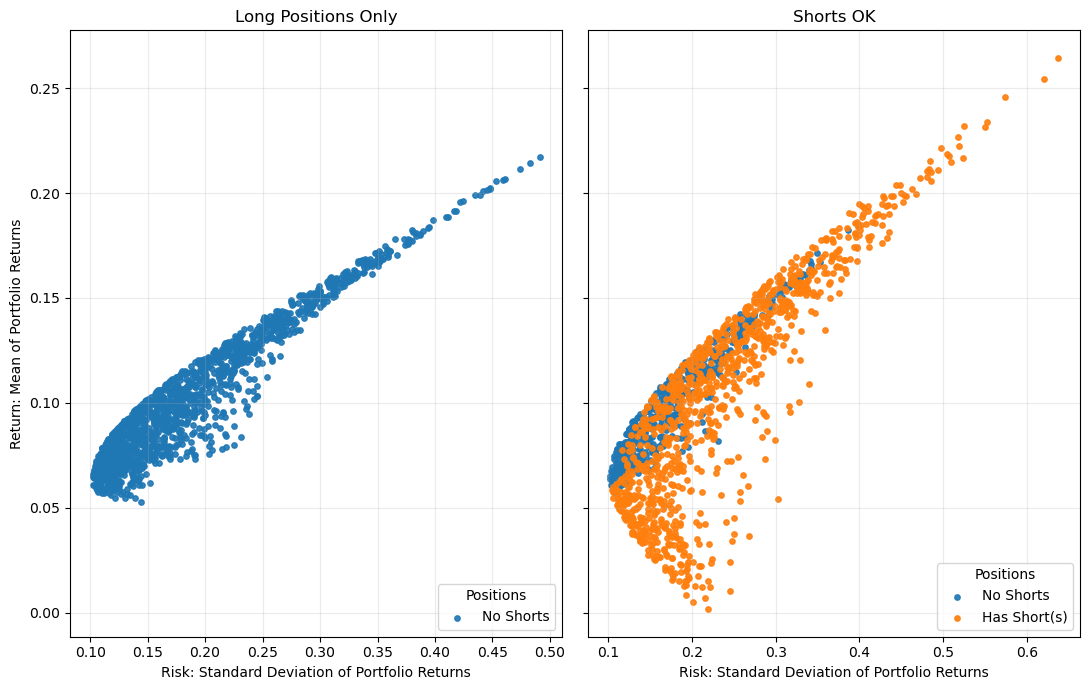

Assets: ['NVDA', 'XOM', 'TLT', 'GLD']
Mean(mu): [0.22 0.08 0.06 0.05]
Vol(sig): [0.5  0.25 0.15 0.16]
Corr matrix:
 [[ 1.00  0.40 -0.20  0.10]
 [ 0.40  1.00 -0.10  0.05]
 [-0.20 -0.10  1.00  0.10]
 [ 0.10  0.05  0.10  1.00]]


In [5]:
# ---- Plot (match R layout) ----
fig, axes = plt.subplots(1, 2, figsize=(11, 7), sharey=True)

# Left: Long-only cloud
ax = axes[0]
ax.scatter(sd_long, ret_long, s=15, alpha=0.9, label='No Shorts')
ax.set_title('Long Positions Only')
ax.set_xlabel('Risk: Standard Deviation of Portfolio Returns')
ax.set_ylabel('Return: Mean of Portfolio Returns')
ax.grid(alpha=0.25)
ax.legend(title='Positions', loc='lower right')

# Right: Shorts OK (color portfolios with short weights)
ax = axes[1]
mask_no = ~flag_mix
mask_sh =  flag_mix
ax.scatter(sd_mix[mask_no], ret_mix[mask_no], s=15, alpha=0.9, label='No Shorts')
ax.scatter(sd_mix[mask_sh], ret_mix[mask_sh], s=15, alpha=0.9, label='Has Short(s)')
ax.set_title('Shorts OK')
ax.set_xlabel('Risk: Standard Deviation of Portfolio Returns')
ax.grid(alpha=0.25)
ax.legend(title='Positions', loc='lower right')

plt.tight_layout()
plt.show()

# ---- (Optional) quick sanity prints ----
print("Assets:", assets)
print("Mean(mu):", mu.round(3))
print("Vol(sig):", sig.round(3))
print("Corr matrix:\n", np.array2string(corr, formatter={'float_kind':lambda x: f'{x: .2f}'}))